<a href="https://colab.research.google.com/github/tedeliott/multi_opti_for_GoldNPs/blob/main/research_project_round_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi optimization for gold nanoparticles

## 1. Dataset

import raw dataset

In [1]:
import pandas as pd
import numpy as np

data = [
    # Sample_ID, inner_index, Date, HAuCl4_mM, PVP_mg_ml, AA_mM, Citrate_mM, pH,
    # Au_flow_rate, reducing_agent_flow_rate_mL_h, Z_Average_nm, PDI, Zeta_mV, note

    ["AuNP_001", "A", "28/04/2026", 1, 10, 20, 0,   3, 30, 30, 104.2, 0.1955, -5.321, ""],
    ["AuNP_002", "B", "28/04/2026", 1, 10, 20, 0,  11, 30, 30, 57.13, 0.4903, -6.766, ""],
    ["AuNP_003", "C", "28/04/2026", 1, 0,  20, 0,   3, 30, 30, 59.02, 0.2634, -21.56, ""],
    ["AuNP_004", "D", "28/04/2026", 1, 0,  20, 0,  11, 30, 30, 23.36, 0.4285, -12.39, ""],

    ["AuNP_005", "A", "07/05/2026", 1, 10, 20, 0,   3, 30, 30, 101.57, 0.1301, -7.395, "check fouling problem"],
    ["AuNP_006", "B", "07/05/2026", 1, 10, 20, 0,   3, 30, 30, 108.7, 0.1357, -6.304, "check fouling problem"],

    ["AuNP_007", "A", "22/05/2026", 1, 10, 20, 2,   3, 30, 30, 139.3, 0.3123, -10.279, "try tube type"],
    ["AuNP_008", "B", "22/05/2026", 1, 10, 20, 2,   3, 30, 30, 151.0, 0.3730, -10.045, "try tube type"],
    ["AuNP_009", "C", "22/05/2026", 1, 10, 20, 2,   3, 30, 30, 217.7, 0.8198, -10.1156, "try tube type"],
    ["AuNP_010", "D", "22/05/2026", 1, 10, 20, 2,   3, 30, 30, 171.9, 0.3971, -10.294, "try tube type"],

    ["AuNP_011", "A", "01/06/2026", 1, 10, 20, 2,  10, 30, 30, 67.163, 0.3107, -14.12, ""],
    ["AuNP_012", "B", "01/06/2026", 1, 10, 20, 0.2, 3, 30, 30, 108.9, 0.1441, -5.829, ""],
    ["AuNP_013", "C", "01/06/2026", 1, 10, 20, 0.2,10, 30, 30, 82.7, 0.3159, -7.157, ""],

    ["AuNP_014", "A", "04/06/2026", 1, 1,  20, 2,   3, 30, 30, 216.0, 0.4702, -7.775, ""],
    ["AuNP_015", "B", "04/06/2026", 1, 1,  20, 2,  10, 30, 30, 18.11, 0.6486, -6.88, ""],
    ["AuNP_016", "C", "04/06/2026", 1, 0,  20, 2,   3, 30, 30, np.nan, np.nan, np.nan, "very slow"],
    ["AuNP_017", "D", "04/06/2026", 1, 0,  20, 2,  10, 30, 30, np.nan, np.nan, np.nan, "very slow"],

    ["AuNP_018", "A", "08/06/2026", 1, 50, 20, 2,   3, 30, 30, 228.0, 0.0912, 1.9043, ""],
    ["AuNP_019", "B", "06/08/2026", 1, 50, 20, 2,  10, 30, 30, 113.6, 0.2568, -2.74, ""],

    ["AuNP_020", "A", "12/06/2026", 1, 30, 20, 2,   3, 30, 30, 143.4, 0.1677, -3.126, ""],
    ["AuNP_021", "B", "12/06/2026", 1, 30, 20, 2,  10, 30, 30, 30.09, 0.4766, -2.422, ""],
    ["AuNP_022", "A", "24/06/2026", 1, 10, 20, 0,   3, 30, 30, 130.7, 0.1219, -5.106333, "AI model round 1"],

    ["AuNP_023", "B", "24/06/2026", 1, 10, 20, 0.2, 3, 30, 30, 156.1, 0.1599, -5.468333, "AI model round 1"],

    ["AuNP_024", "C", "24/06/2026", 1, 5,  20, 0,   3, 30, 30, 132.2, 0.1386, -6.398333, "AI model round 1"],

    ["AuNP_025", "D", "24/06/2026", 1, 5,  20, 0.2, 3, 30, 30, 114.5, 0.1433, -7.636,    "AI model round 1"],

    ["AuNP_026", "E", "24/06/2026", 1, 10, 20, 0.5, 3, 30, 30, 144.2, 0.1408, -5.048333, "AI model round 1"],

    ["AuNP_027", "F", "24/06/2026", 1, 10, 20, 0,   5, 30, 30, 101.8, 0.1884, -4.771,    "AI model round 1"],
    ["AuNP_028", "A", "26/06/2026", 1, 1, 20, 0.0, 3, 30, 30, 92.07, 0.1527, -10.25,     "AI model round 2"],

    ["AuNP_029", "B", "26/06/2026", 1, 1, 20, 0.1, 3, 30, 30, 107.2, 0.1533, -9.735,     "AI model round 2"],

    ["AuNP_030", "C", "26/06/2026", 1, 1, 20, 0.2, 3, 30, 30, 85.82, 0.1618, -10.136333, "AI model round 2"],

    ["AuNP_031", "D", "26/06/2026", 1, 5, 20, 0.0, 3, 30, 30, 112.2, 0.1155, -6.273,    "AI model round 2"],

    ["AuNP_032", "E", "26/06/2026", 1, 5, 20, 0.1, 3, 30, 30, 103.4, 0.1073, -6.46,     "AI model round 2"],

    ["AuNP_033", "F", "26/06/2026", 1, 5, 20, 0.2, 3, 30, 30, 98.18, 0.1255, -7.914333, "AI model round 2"],
]

columns = [
    "Sample_ID",
    "inner_index",
    "Date",
    "HAuCl4_mM",
    "PVP_mg_ml",
    "AA_mM",
    "Citrate_mM",
    "pH",
    "Au_flow_rate",
    "reducing_agent_flow_rate_mL_h",
    "Z_Average_nm",
    "PDI",
    "Zeta_mV",
    "note"
]

df_raw = pd.DataFrame(data, columns=columns)

df_raw["Date"] = pd.to_datetime(df_raw["Date"], dayfirst=True)

df_raw

,Sample_ID,inner_index,Date,HAuCl4_mM,PVP_mg_ml,AA_mM,Citrate_mM,pH,Au_flow_rate,reducing_agent_flow_rate_mL_h,Z_Average_nm,PDI,Zeta_mV,note
0,AuNP_001,A,2026-04-28,1,10,20,0.0,3,30,30,104.200,0.1955,-5.321000,
1,AuNP_002,B,2026-04-28,1,10,20,0.0,11,30,30,57.130,0.4903,-6.766000,
2,AuNP_003,C,2026-04-28,1,0,20,0.0,3,30,30,59.020,0.2634,-21.560000,
3,AuNP_004,D,2026-04-28,1,0,20,0.0,11,30,30,23.360,0.4285,-12.390000,
4,AuNP_005,A,2026-05-07,1,10,20,0.0,3,30,30,101.570,0.1301,-7.395000,check fouling problem
5,AuNP_006,B,2026-05-07,1,10,20,0.0,3,30,30,108.700,0.1357,-6.304000,check fouling problem
6,AuNP_007,A,2026-05-22,1,10,20,2.0,3,30,30,139.300,0.3123,-10.279000,try tube type
7,AuNP_008,B,2026-05-22,1,10,20,2.0,3,30,30,151.000,0.3730,-10.045000,try tube type
8,AuNP_009,C,2026-05-22,1,10,20,2.0,3,30,30,217.700,0.8198,-10.115600,try tube type
9,AuNP_010,D,2026-05-22,1,10,20,2.0,3,30,30,171.900,0.3971,-10.294000,try tube type


delete ineffective data(e.g. very slow data)

In [2]:
df_model = df_raw.dropna(subset=["Z_Average_nm", "PDI", "Zeta_mV"]).copy()

df_model

,Sample_ID,inner_index,Date,HAuCl4_mM,PVP_mg_ml,AA_mM,Citrate_mM,pH,Au_flow_rate,reducing_agent_flow_rate_mL_h,Z_Average_nm,PDI,Zeta_mV,note
0,AuNP_001,A,2026-04-28,1,10,20,0.0,3,30,30,104.200,0.1955,-5.321000,
1,AuNP_002,B,2026-04-28,1,10,20,0.0,11,30,30,57.130,0.4903,-6.766000,
2,AuNP_003,C,2026-04-28,1,0,20,0.0,3,30,30,59.020,0.2634,-21.560000,
3,AuNP_004,D,2026-04-28,1,0,20,0.0,11,30,30,23.360,0.4285,-12.390000,
4,AuNP_005,A,2026-05-07,1,10,20,0.0,3,30,30,101.570,0.1301,-7.395000,check fouling problem
5,AuNP_006,B,2026-05-07,1,10,20,0.0,3,30,30,108.700,0.1357,-6.304000,check fouling problem
6,AuNP_007,A,2026-05-22,1,10,20,2.0,3,30,30,139.300,0.3123,-10.279000,try tube type
7,AuNP_008,B,2026-05-22,1,10,20,2.0,3,30,30,151.000,0.3730,-10.045000,try tube type
8,AuNP_009,C,2026-05-22,1,10,20,2.0,3,30,30,217.700,0.8198,-10.115600,try tube type
9,AuNP_010,D,2026-05-22,1,10,20,2.0,3,30,30,171.900,0.3971,-10.294000,try tube type


input variable X

In [3]:
input_cols = [
    "HAuCl4_mM",
    "PVP_mg_ml",
    "AA_mM",
    "Citrate_mM",
    "pH",
    "Au_flow_rate",
    "reducing_agent_flow_rate_mL_h"
]

X = df_model[input_cols].values

X

array([[ 1. , 10. , 20. ,  0. ,  3. , 30. , 30. ],
       [ 1. , 10. , 20. ,  0. , 11. , 30. , 30. ],
       [ 1. ,  0. , 20. ,  0. ,  3. , 30. , 30. ],
       [ 1. ,  0. , 20. ,  0. , 11. , 30. , 30. ],
       [ 1. , 10. , 20. ,  0. ,  3. , 30. , 30. ],
       [ 1. , 10. , 20. ,  0. ,  3. , 30. , 30. ],
       [ 1. , 10. , 20. ,  2. ,  3. , 30. , 30. ],
       [ 1. , 10. , 20. ,  2. ,  3. , 30. , 30. ],
       [ 1. , 10. , 20. ,  2. ,  3. , 30. , 30. ],
       [ 1. , 10. , 20. ,  2. ,  3. , 30. , 30. ],
       [ 1. , 10. , 20. ,  2. , 10. , 30. , 30. ],
       [ 1. , 10. , 20. ,  0.2,  3. , 30. , 30. ],
       [ 1. , 10. , 20. ,  0.2, 10. , 30. , 30. ],
       [ 1. ,  1. , 20. ,  2. ,  3. , 30. , 30. ],
       [ 1. ,  1. , 20. ,  2. , 10. , 30. , 30. ],
       [ 1. , 50. , 20. ,  2. ,  3. , 30. , 30. ],
       [ 1. , 50. , 20. ,  2. , 10. , 30. , 30. ],
       [ 1. , 30. , 20. ,  2. ,  3. , 30. , 30. ],
       [ 1. , 30. , 20. ,  2. , 10. , 30. , 30. ],
       [ 1. , 10. , 20. ,  0. ,

adjusting objectives

set the dpi=0.2, first time i do not set the target cause the dpi is varing, the ai-guided experiments are so good in dpi so i dissmiss the dpi target

In [4]:
pdi_target = 0.2

df_model["pdi_penalty"] = np.maximum(df_model["PDI"] - pdi_target, 0)
df_model["abs_zeta"] = abs(df_model["Zeta_mV"])


In [5]:


objective_cols = [
    "pdi_penalty",
     "abs_zeta"
]

Y_objectives = df_model[objective_cols].values

Y_objectives

array([[ 0.      ,  5.321   ],
       [ 0.2903  ,  6.766   ],
       [ 0.0634  , 21.56    ],
       [ 0.2285  , 12.39    ],
       [ 0.      ,  7.395   ],
       [ 0.      ,  6.304   ],
       [ 0.1123  , 10.279   ],
       [ 0.173   , 10.045   ],
       [ 0.6198  , 10.1156  ],
       [ 0.1971  , 10.294   ],
       [ 0.1107  , 14.12    ],
       [ 0.      ,  5.829   ],
       [ 0.1159  ,  7.157   ],
       [ 0.2702  ,  7.775   ],
       [ 0.4486  ,  6.88    ],
       [ 0.      ,  1.9043  ],
       [ 0.0568  ,  2.74    ],
       [ 0.      ,  3.126   ],
       [ 0.2766  ,  2.422   ],
       [ 0.      ,  5.106333],
       [ 0.      ,  5.468333],
       [ 0.      ,  6.398333],
       [ 0.      ,  7.636   ],
       [ 0.      ,  5.048333],
       [ 0.      ,  4.771   ],
       [ 0.      , 10.25    ],
       [ 0.      ,  9.735   ],
       [ 0.      , 10.136333],
       [ 0.      ,  6.273   ],
       [ 0.      ,  6.46    ],
       [ 0.      ,  7.914333]])

## 2. Establish single scalarizing function with **Chimera**

In [6]:
pip install matter-chimera

In [7]:
from chimera import Chimera

chimera = Chimera(
    tolerances=[0.2, 0.1],
    absolutes=[False, False],
    goals=["min", "max"]
)

y_chimera = chimera.scalarize(Y_objectives)

df_model["chimera_merit"] = y_chimera

df_model[[
    "Sample_ID",
    "PDI",
    "Z_Average_nm",
    "Zeta_mV",
    "abs_zeta",
    "pdi_penalty",
    "chimera_merit"
]]

,Sample_ID,PDI,Z_Average_nm,Zeta_mV,abs_zeta,pdi_penalty,chimera_merit
0,AuNP_001,0.1955,104.200,-5.321000,5.321000,0.0000,0.427160
1,AuNP_002,0.4903,57.130,-6.766000,6.766000,0.2903,0.687281
2,AuNP_003,0.2634,59.020,-21.560000,21.560000,0.0634,0.000000
3,AuNP_004,0.4285,23.360,-12.390000,12.390000,0.2285,0.628628
4,AuNP_005,0.1301,101.570,-7.395000,7.395000,0.0000,0.365092
5,AuNP_006,0.1357,108.700,-6.304000,6.304000,0.0000,0.397742
6,AuNP_007,0.3123,139.300,-10.279000,10.279000,0.1123,0.278782
7,AuNP_008,0.3730,151.000,-10.045000,10.045000,0.1730,0.575954
8,AuNP_009,0.8198,217.700,-10.115600,10.115600,0.6198,1.000000
9,AuNP_010,0.3971,171.900,-10.294000,10.294000,0.1971,0.598827


## 3. Model

process 1: investigating trends

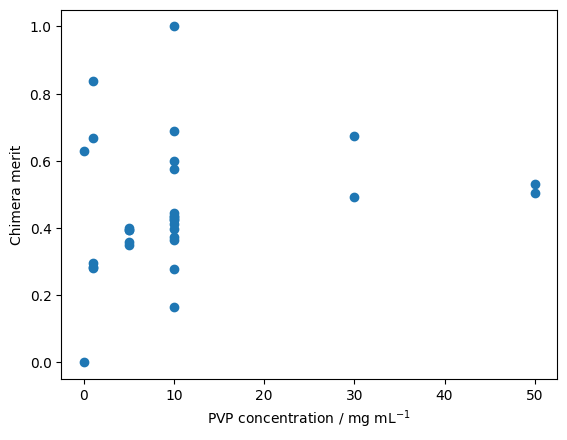

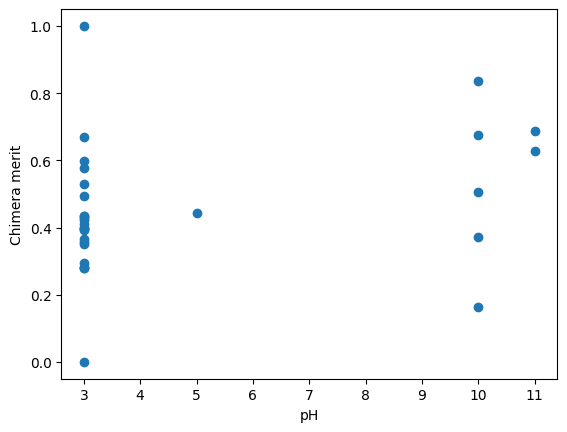

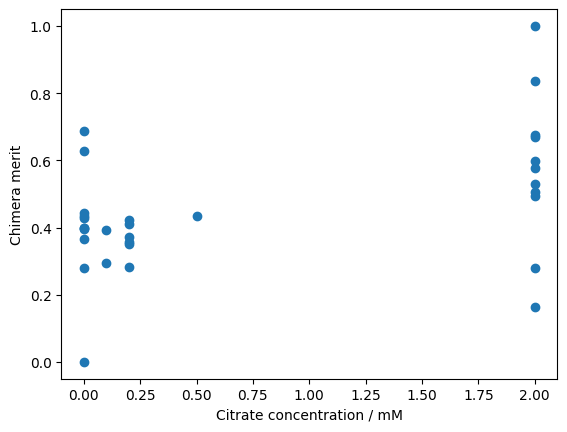

In [8]:
import matplotlib.pyplot as plt

plt.scatter(df_model["PVP_mg_ml"], df_model["chimera_merit"])
plt.xlabel("PVP concentration / mg mL$^{-1}$")
plt.ylabel("Chimera merit")
plt.show()

plt.scatter(df_model["pH"], df_model["chimera_merit"])
plt.xlabel("pH")
plt.ylabel("Chimera merit")
plt.show()

plt.scatter(df_model["Citrate_mM"], df_model["chimera_merit"])
plt.xlabel("Citrate concentration / mM")
plt.ylabel("Chimera merit")
plt.show()

process 2: surrogate model

In [9]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

y = df_model["chimera_merit"].values

kernel = ConstantKernel(1.0) * Matern(nu=2.5) + WhiteKernel()

gp = make_pipeline(
    StandardScaler(),
    GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=0)
)

gp.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gaussianprocessregressor',
                 GaussianProcessRegressor(kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1),
                                          normalize_y=True, random_state=0))])

In [10]:
from scipy.stats import norm

In [11]:
def expected_improvement_minimization(X_candidates, gp, y_observed, xi=0.01):
    """
    Expected Improvement for minimization.

    X_candidates: candidate experimental conditions
    gp: trained Gaussian Process pipeline
    y_observed: observed Chimera merit values
    xi: exploration parameter
    """

    mu, sigma = gp.predict(X_candidates, return_std=True)

    y_best = np.min(y_observed)

    improvement = y_best - mu - xi

    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

    ei[sigma == 0.0] = 0.0

    return ei, mu, sigma

In [13]:
candidate_data = []

for pvp in [ 0.5, 1, 1.5, 2, 3, 4, 5]:
    for citrate in [0, 0.05, 0.1, 0.15, 0.2, 0.3]:
        for ph in [3, 3.5, 4, 4.5, 5]:
            candidate_data.append([
                1,       # HAuCl4_mM
                pvp,     # PVP_mg_ml
                20,      # AA_mM
                citrate, # Citrate_mM
                ph,      # pH
                30,      # Au_flow_rate
                30       # reducing_agent_flow_rate_mL_h
            ])

X_candidates = np.array(candidate_data)
candidate_df = pd.DataFrame(X_candidates, columns=input_cols)

In [14]:
ei, mu, sigma = expected_improvement_minimization(
    X_candidates,
    gp,
    y,
    xi=0.01
)

candidate_df["predicted_merit_mu"] = mu
candidate_df["uncertainty_sigma"] = sigma
candidate_df["EI"] = ei

candidate_df.sort_values("EI", ascending=False).head(10)

,HAuCl4_mM,PVP_mg_ml,AA_mM,Citrate_mM,pH,Au_flow_rate,reducing_agent_flow_rate_mL_h,predicted_merit_mu,uncertainty_sigma,EI
0,1.0,0.5,20.0,0.00,3.0,30.0,30.0,0.301462,0.166683,0.001998
5,1.0,0.5,20.0,0.05,3.0,30.0,30.0,0.301752,0.166126,0.001951
1,1.0,0.5,20.0,0.00,3.5,30.0,30.0,0.311588,0.169447,0.001884
10,1.0,0.5,20.0,0.10,3.0,30.0,30.0,0.304226,0.166112,0.001876
30,1.0,1.0,20.0,0.00,3.0,30.0,30.0,0.304694,0.165952,0.001852
6,1.0,0.5,20.0,0.05,3.5,30.0,30.0,0.311827,0.168979,0.001846
35,1.0,1.0,20.0,0.05,3.0,30.0,30.0,0.304938,0.165356,0.001806
11,1.0,0.5,20.0,0.10,3.5,30.0,30.0,0.313987,0.168964,0.001785
15,1.0,0.5,20.0,0.15,3.0,30.0,30.0,0.308664,0.166628,0.001783
31,1.0,1.0,20.0,0.00,3.5,30.0,30.0,0.314494,0.168783,0.001759
